In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import scipy

from scipy.ndimage import uniform_filter1d


plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [2]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

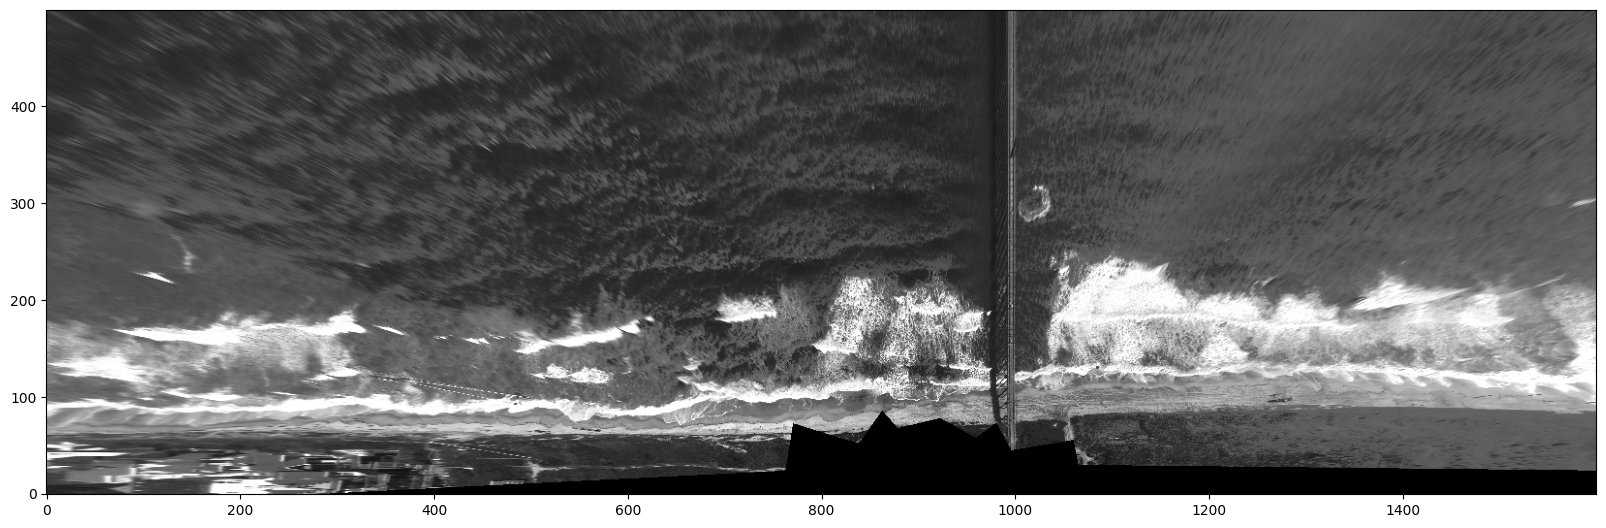

In [3]:
cap = cv2.VideoCapture(os.path.join(dir, file))
_, frame = cap.read()
frame = frame[..., 0]
plt.figure(figsize=(20, 30))
plt.imshow(frame.T)
cap.release()
cv2.destroyAllWindows()

In [4]:
# Create Timestacks for each cross-shore location
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))


for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


100%|██████████| 3840/3840 [00:05<00:00, 691.92it/s]


100%|██████████| 1600/1600 [00:48<00:00, 32.69it/s]


(300.0, 600.0)

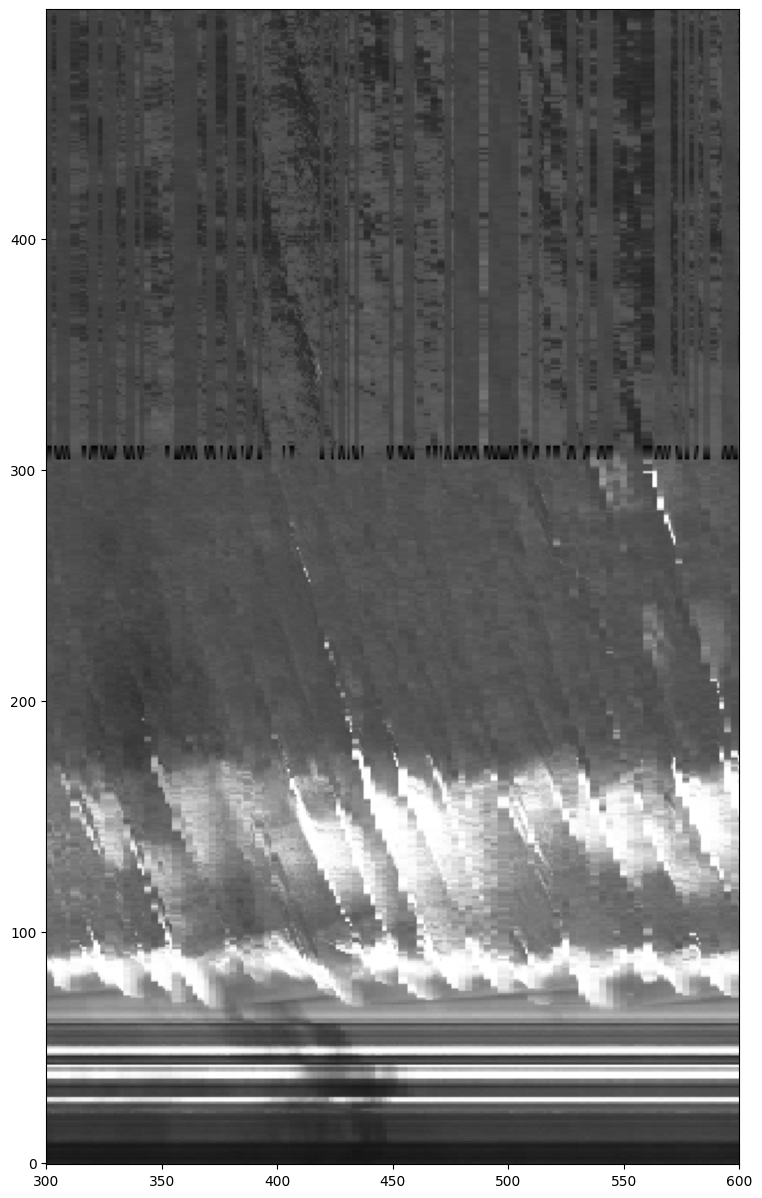

In [5]:
# Forward Fill Missing Data
for c in tqdm(range(timestack.shape[1])):
    tt = timestack[:, c, :].T
    # tt = t.copy()
    tt[tt==0] = np.nan
    extend = 50
    mask = np.isnan(tt)
    # mask = scipy.ndimage.binary_dilation(np.isnan(tt), structure=(np.ones((2*extend+1, 1))))

    idx = np.where(~mask,np.arange(mask.shape[1]),0)
    np.maximum.accumulate(idx,axis=1, out=idx)
    tt[mask] = tt[np.nonzero(mask)[0], idx[mask]]
    tt[np.isnan(tt)] = 0
    # timestack[:, c, :] = tt.T

plt.figure(figsize=(15, 15))
plt.imshow(timestack[:, 7, :].T)
plt.xlim([300, 600])

In [7]:
def normalize(x, scale=255):
    x = (x - x.min())
    return x/x.max() * scale

(300.0, 600.0)

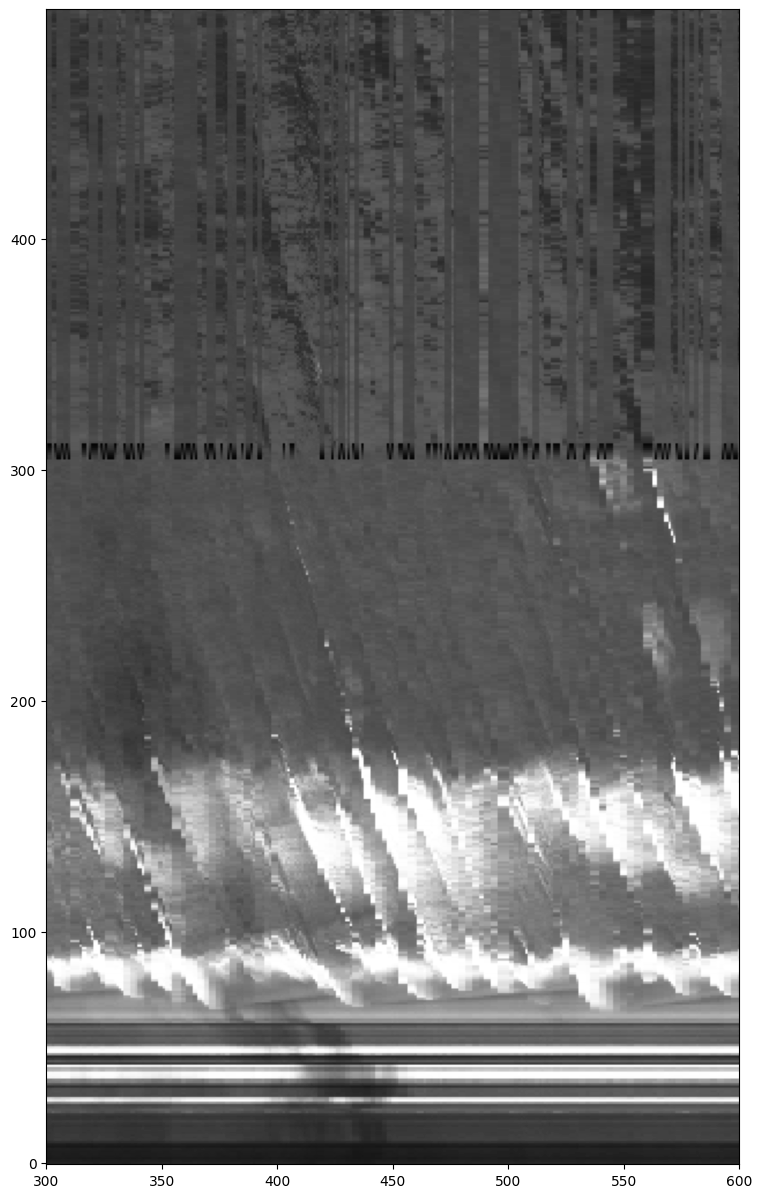

In [8]:
plt.figure(figsize=(15, 15))
plt.imshow(timestack[:, 5, :].T)
plt.xlim([300, 600])

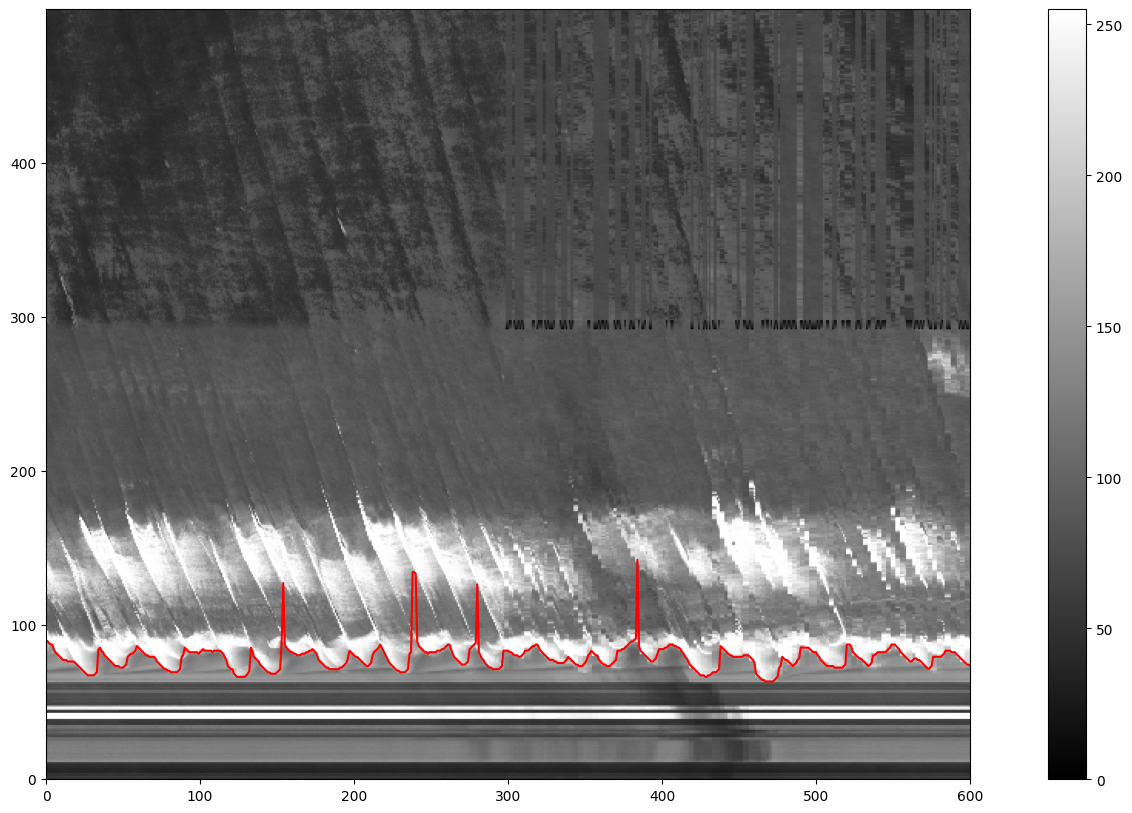

In [12]:
from scipy.ndimage import binary_erosion, binary_dilation, binary_closing
plt.figure(figsize=(20, 10))
t = timestack[:, 50, :].T
t[np.isnan(t)] = 0
# th3 = cv2.threshold(t,127,255,cv2.THRESH_BINARY)

# plt.imshow(th3)
plt.imshow(t, vmin=0, vmax=255)
# The foam layer here is kind of a hack
foam = binary_dilation(binary_erosion(t > 170, iterations=2), iterations=2)
# plt.imshow(foam, cmap='Reds', alpha=0.45)
plt.colorbar()
plt.xlim([0, 600])
plt.plot(np.arange(3840), np.argmax(foam, axis=0), c='r')



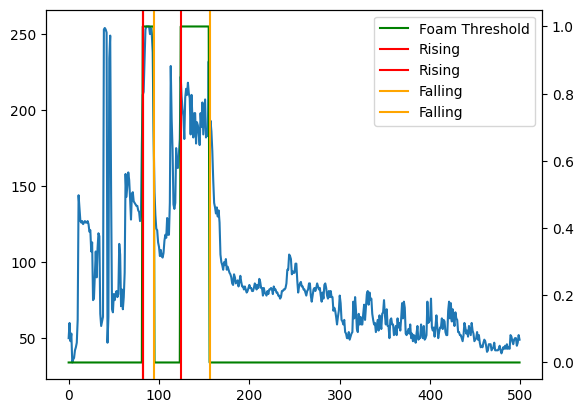

In [13]:
plt.plot(t[:, 100])
plt.twinx().plot(foam[:, 100], c='g', label='Foam Threshold')
plt.axvline(np.argmax(foam, axis=0)[100], c='r')

def rising_edge(data, thresh):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == 1)
    return pos

def falling_edge(data, thresh):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [-1, 1]) == 1)
    return pos

for x in rising_edge(foam[:, 100], 1)[0]:
    plt.axvline(x, c='r', label='Rising')
for x in falling_edge(foam[:, 100], 1)[0]:
    plt.axvline(x, c='orange', label='Falling')
plt.legend()

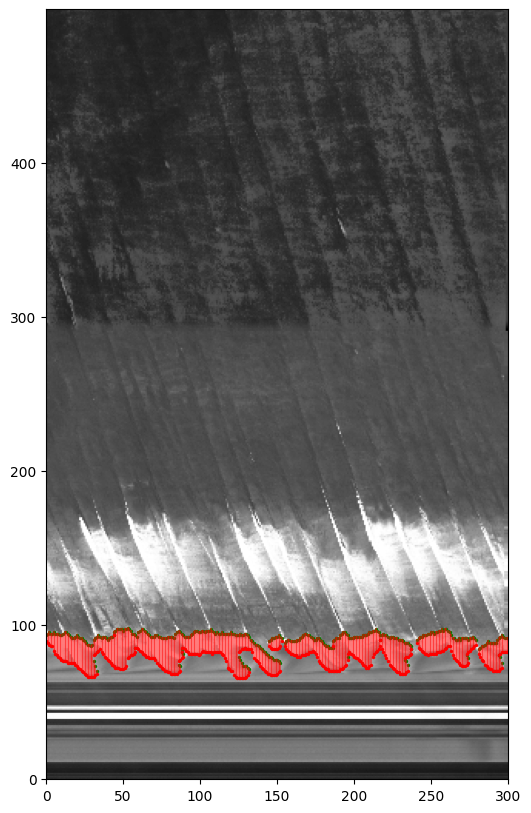

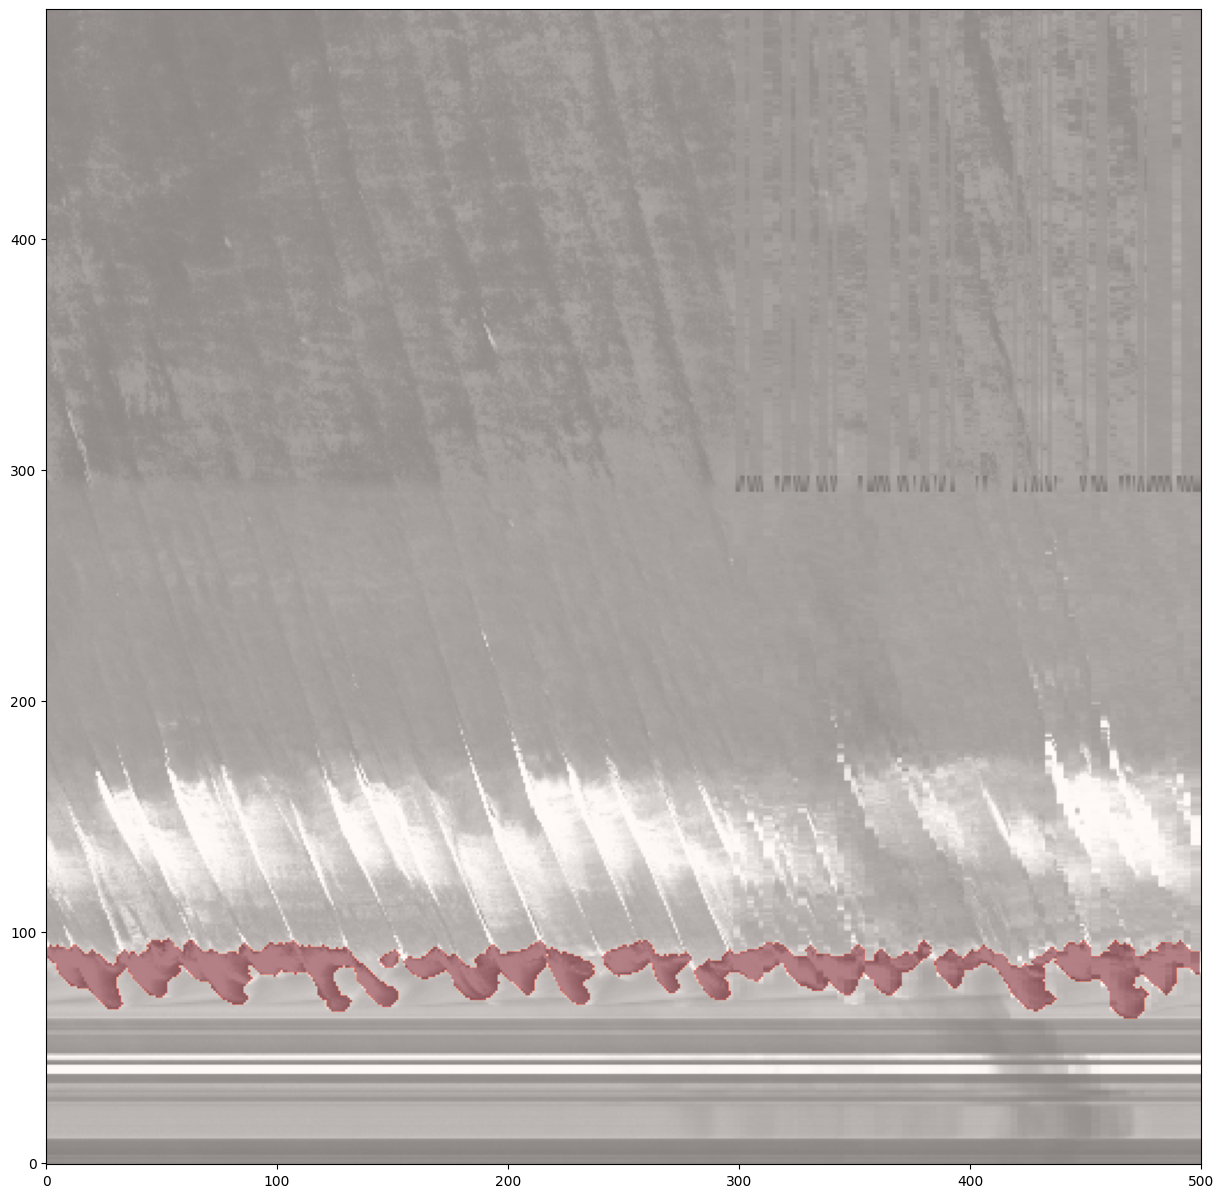

In [14]:
t = timestack[:, 51, :].T
plt.figure(figsize=(10, 10))
plt.imshow(t)

plt.xlim([0, 300])
fe_max = 0
swash_extent = np.zeros_like(t).astype(bool)
xs = np.arange(500)

for i in range(500):
    re = rising_edge(foam[:, i], 1)[0] - 1
    fe = falling_edge(foam[:, i], 1)[0]
    if not len(fe) == 0 and (fe_max == 0 or fe[0] < 1.25 * fe_max):
        fe_max = max(fe_max, fe[0])
    for j, _ in enumerate(re):
        if fe[j] > fe_max:
            continue
        plt.scatter(i, re[j], c='r', s=2)
        plt.scatter(i, fe[j], c='g', s=2)
        plt.plot((i, i), (re[j], fe[j]), c='r', alpha=0.5)
        swash_extent[:, i] = swash_extent[:, i] | ((xs > re[j]) & (xs < fe[j]))
plt.figure(figsize=(15, 15))
plt.xlim([0, 500])
plt.imshow(t)

plt.imshow(swash_extent, cmap='Reds', alpha=0.5)


In [ ]:
# plt.imshow(t)
plt.figure(figsize=(10, 10))
plt.contourf(*np.mgrid[0:t.shape[1], 0:t.shape[0]], t.T)
plt.colorbar()
plt.contour(*np.mgrid[0:t.shape[1], 0:t.shape[0]], swash_extent.T, levels=1, colors='r', linewidths=0.5)
plt.xlim([0, 300])
plt.ylim([0, 300])
plt.figure(figsize=(10, 10))
plt.contourf(*np.mgrid[0:t.shape[1], 0:t.shape[0]], normalize(t-t.mean(axis=0)).T, levels=10)
plt.colorbar()
plt.contour(*np.mgrid[0:t.shape[1], 0:t.shape[0]], swash_extent.T, levels=1, colors='r', linewidths=0.5)
plt.xlim([0, 600])
plt.ylim([0, 300])

In [509]:
timestack.shape

(3840, 1600, 500)

In [527]:
foam.shape

(500, 3840)

In [16]:
swash_extent = np.zeros_like(timestack).astype(bool)

for k in tqdm(range(1600)):
    t = timestack[:, k, :].T
    foam = binary_dilation(binary_erosion(t > 170, iterations=2), iterations=2)
    fe_max = 0
    xs = np.arange(500)

    for i in range(50):
        re = rising_edge(foam[:, i], 1)[0] - 1
        fe = falling_edge(foam[:, i], 1)[0]
        if not len(fe) == 0 and (fe_max == 0 or fe[0] < 1.25 * fe_max):
            fe_max = max(fe_max, fe[0])
        for j, _ in enumerate(re):
            if fe[j] > fe_max:
                continue
            # plt.scatter(i, re[j], c='r', s=2)
            # plt.scatter(i, fe[j], c='g', s=2)
            # plt.plot((i, i), (re[j], fe[j]), c='r', alpha=0.5)
            swash_extent[i, k, :] = swash_extent[i, k, :] | ((xs > re[j]) & (xs < fe[j]))



100%|██████████| 1600/1600 [01:00<00:00, 26.42it/s]


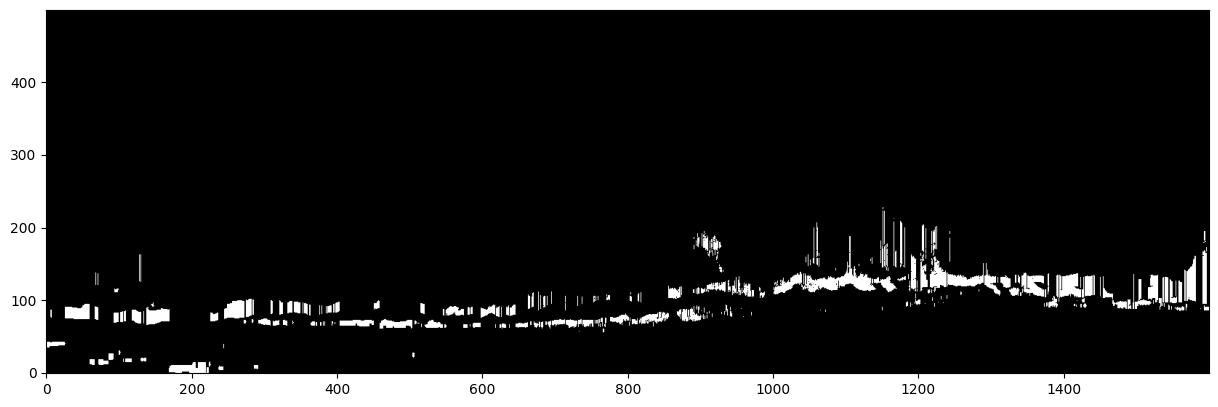

: 

In [18]:
plt.figure(figsize=(15, 5))
plt.imshow(swash_extent[20, :, :].T)

In [542]:
out = cv2.VideoWriter('swash.avi',cv2.VideoWriter_fourcc('M','P','N','G'), 20, (H, W), 0)
for i in tqdm(range(200)):
    out.write(swash_extent[i, ...].astype(np.uint8).T[::-1, :]*255)
out.release()
cv2.destroyAllWindows()
! ffmpeg -i swash.avi -c:v libx264 swash.mp4 -y

100%|██████████| 200/200 [00:00<00:00, 214.59it/s]

ffmpeg version 7.0 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.3.9.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopenvino -

[out#0/mp4 @ 0x14fe36a80] video:1548KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.206078%
frame=  200 fps=0.0 q=-1.0 Lsize=    1551KiB time=00:00:09.90 bitrate=1283.7kbits/s speed=27.8x    
[libx264 @ 0x14fe3d640] frame I:1     Avg QP:14.86  size:  9358
[libx264 @ 0x14fe3d640] frame P:51    Avg QP:15.79  size: 10352
[libx264 @ 0x14fe3d640] frame B:148   Avg QP:21.42  size:  7076
[libx264 @ 0x14fe3d640] consecutive B-frames:  1.0%  1.0%  0.0% 98.0%
[libx264 @ 0x14fe3d640] mb I  I16..4: 64.9% 26.0%  9.1%
[libx264 @ 0x14fe3d640] mb P  I16..4:  1.0%  1.1%  3.1%  P16..4:  3.4%  3.0%  2.0%  0.0%  0.0%    skip:86.5%
[libx264 @ 0x14fe3d640] mb B  I16..4:  0.2%  0.6%  0.5%  B16..8:  6.8%  3.3%  2.2%  direct: 1.2%  skip:85.2%  L0:49.0% L1:43.3% BI: 7.7%
[libx264 @ 0x14fe3d640] 8x8 transform intra:31.7% inter:0.9%
[libx264 @ 0x14fe3d640] coded y intra: 24.1% inter: 3.6%
[libx264 @ 0x14fe3d640] i16 v,h,dc,p: 85% 12%  3%  0%
[libx264 @ 0x14fe3d640] i8 v,h,dc

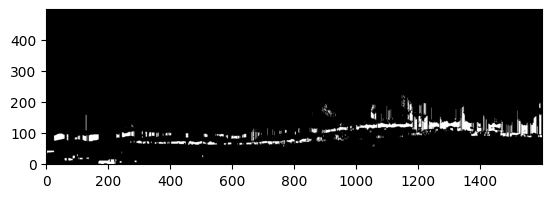

In [537]:
plt.imshow(swash_extent[53, ...].T)